# 07 Vg-eqtl inspection

## Genetic Variance (Vg) Metrics

### **vg_predicted**
- **Type:** Float
- **Description:** Total predicted genetic variance for this gene
- **Formula:** Σ[2 × AF × (1 - AF) × β²] across all variants
- **Note:** Primary Vg metric using observed allele frequencies

### **vg_predicted_perm**
- **Type:** Float
- **Description:** Total predicted genetic variance using permuted allele frequencies
- **Formula:** Σ[2 × perm_AF × (1 - perm_AF) × β²]
- **Note:** Used as null expectation for selection analyses

### **vg_common**
- **Type:** Float
- **Description:** Genetic variance contribution from common variants (AF ≥ 0.05)
- **Calculation:** Sum of vg_contribution where AF ≥ 0.05

### **vg_rare**
- **Type:** Float
- **Description:** Genetic variance contribution from rare variants (AF < 0.05)
- **Calculation:** Sum of vg_contribution where AF < 0.05

### **vg_common_perm**
- **Type:** Float
- **Description:** Genetic variance from common variants using permuted AFs
- **Note:** Only present when permuted AFs are available

### **vg_rare_perm**
- **Type:** Float
- **Description:** Genetic variance from rare variants using permuted AFs
- **Note:** Only present when permuted AFs are available

## **gene_characterstics.tsv**
- n_distinct_tss - TSS counts




In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '07_vg_inspection'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [3]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [4]:
NOTEBOOK_NAME = '07_vg_inspection'

SOURCE_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']
PLOT_LABELS = {
    'clingen': 'ClinGen_HI_Gnomad',
    'clingen_null': 'ClinGen_HI_Synth',
    'background': 'Background_Gnomad',
    'background_null': 'Background_Synth',
}

palette = {
    'background': SOURCE_PALETTE['background'],
    'background_null': SOURCE_PALETTE['background_null'],
    'clingen': SOURCE_PALETTE['clingen'],
    'clingen_null': SOURCE_PALETTE['clingen_null'],
}

required_cols = [
    'source', 'gene_symbol',
    'vg_predicted', 'vg_predicted_perm',
    'vg_common', 'vg_common_perm',
    'vg_rare', 'vg_rare_perm',
    'n_variants_common', 'n_variants_rare', 'variants_per_kb',
    'loeuf_score',
    'vg_eqtl'
]

all_genes = pl.concat([df_real, df_synth], how='diagonal_relaxed')
missing_cols = [c for c in required_cols if c not in all_genes.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

is_synth = pl.col('source').str.contains('null')

plot_df = (
    all_genes
    .select(required_cols)
    .with_columns([
        pl.when(is_synth).then(pl.col('vg_predicted_perm')).otherwise(pl.col('vg_predicted')).alias('vg_total_for_plot'),
        pl.when(is_synth).then(pl.col('vg_common_perm')).otherwise(pl.col('vg_common')).alias('vg_common_for_plot'),
        pl.when(is_synth).then(pl.col('vg_rare_perm')).otherwise(pl.col('vg_rare')).alias('vg_rare_for_plot'),
    ])
    .with_columns([
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_rare_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_rare_fraction'),
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_common_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_common_fraction'),
    ])
    .filter(pl.col('source').is_in(SOURCE_ORDER))
    .drop_nulls(subset=['source', 'vg_total_for_plot'])
    .to_pandas()
)

plot_df['source_label'] = plot_df['source'].map(PLOT_LABELS)
source_label_order = [PLOT_LABELS[s] for s in SOURCE_ORDER]
palette_by_label = {PLOT_LABELS[s]: palette[s] for s in SOURCE_ORDER}

print('Phase 2 config and shared data prepared.')

REAL_POOL_LABEL = 'ClinGen HI + Background (real genes)'
AF_STACK_COLORS = {
    'Rare (AF < 0.05)': '#0F766E',
    'Common (AF >= 0.05)': '#D1D5DB',
}
POOL_SCATTER_COLOR = '#2563EB'

real_pooled_df = plot_df.loc[plot_df['source'].isin(['clingen', 'background'])].copy()
real_pooled_df['real_pool_label'] = REAL_POOL_LABEL

print('Pooled real-gene view prepared.')


Phase 2 config and shared data prepared.
Pooled real-gene view prepared.


In [5]:
GENE_CHARACTERISTICS = "/Users/markus/in-silico-vg-analysis/07_permutations/gene_characteristics.tsv"

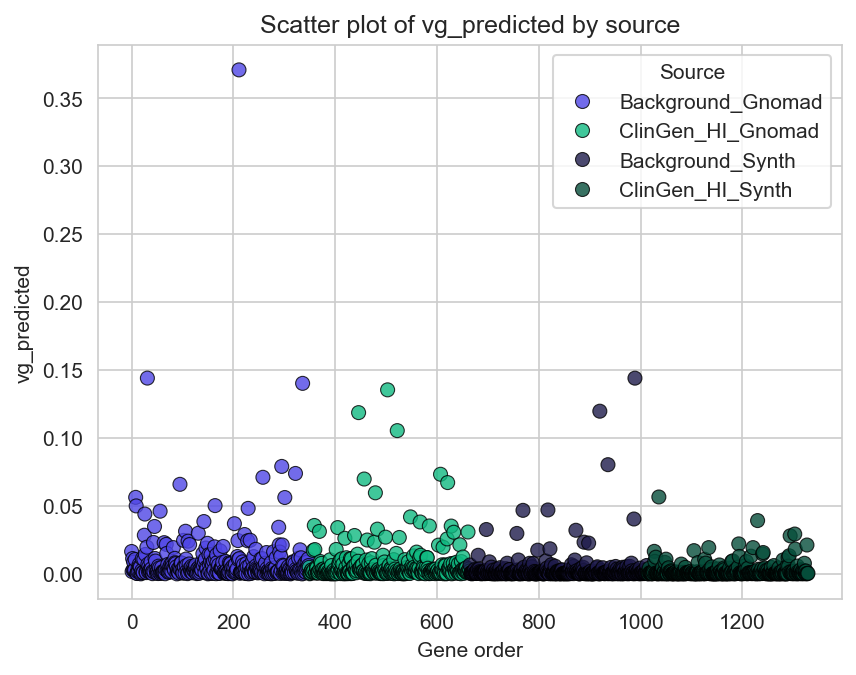

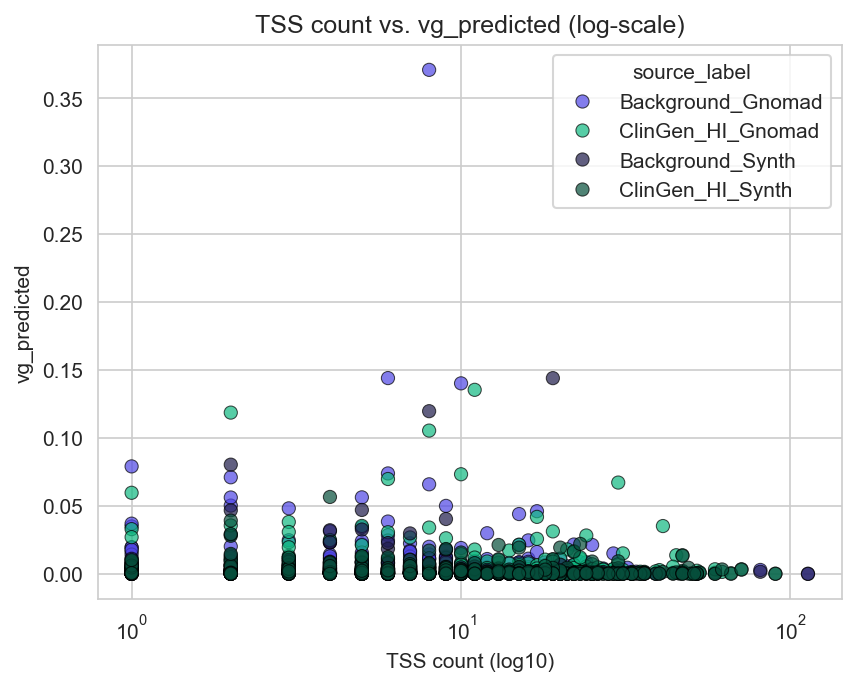

In [6]:
# -------------------------------------------------
# Scatter plot of vg_predicted (colored by source)
# -------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Build the same palette you use for the other plots
palette = {PLOT_LABELS[s]: SOURCE_PALETTE[s] for s in SOURCE_ORDER}

sns.scatterplot(
    data=plot_df,
    x=range(len(plot_df)),
    y="vg_total_for_plot",
    hue="source_label",
    palette=palette,
    s=45, edgecolor="k", alpha=0.8
)
plt.title("Scatter plot of vg_predicted by source")
plt.xlabel("Gene order")
plt.ylabel("vg_predicted")
plt.legend(title="Source")
plt.show()

# -------------------------------------------------
# Scatter plot of TSS counts vs vg_predicted (log-scale TSS)
# -------------------------------------------------
gene_char = pl.read_csv(GENE_CHARACTERISTICS, separator="\t").to_pandas()
tss_df = gene_char[["gene_name", "n_distinct_tss"]]

df_merge = plot_df.merge(tss_df, left_on="gene_symbol", right_on="gene_name", how="left")

sns.scatterplot(
    data=df_merge,
    x="n_distinct_tss",
    y="vg_total_for_plot",
    hue="source_label",
    palette=palette,
    s=40, edgecolor="k", alpha=0.7
)
plt.title("TSS count vs. vg_predicted (log-scale)")
plt.xlabel("TSS count (log10)")
plt.ylabel("vg_predicted")
plt.xscale('log')
plt.show()

## Pooled Real-Gene View

For analyses where the effect is expected across all real genes, pool `clingen` and `background` together and do not split by cohort.

This section therefore uses only the real datasets:
- `clingen` and `background`
- observed columns `vg_predicted`, `vg_common`, `vg_rare`
- `vg_eqtl` for pooled correlation inspection

The synthetic `*_null` datasets are not used in this pooled view.


Pooled real-gene summary (ClinGen HI + Background combined; no null):
 n_genes  median_total_vg  mean_total_vg  median_common_vg  median_rare_vg  median_rare_fraction  mean_rare_fraction
     665         0.002797        0.00804          0.001935        0.000589               0.22629             0.30501

Spearman(total predicted Vg, vg_eqtl) across pooled real genes: rho=0.494, p=7.18e-40, n=628


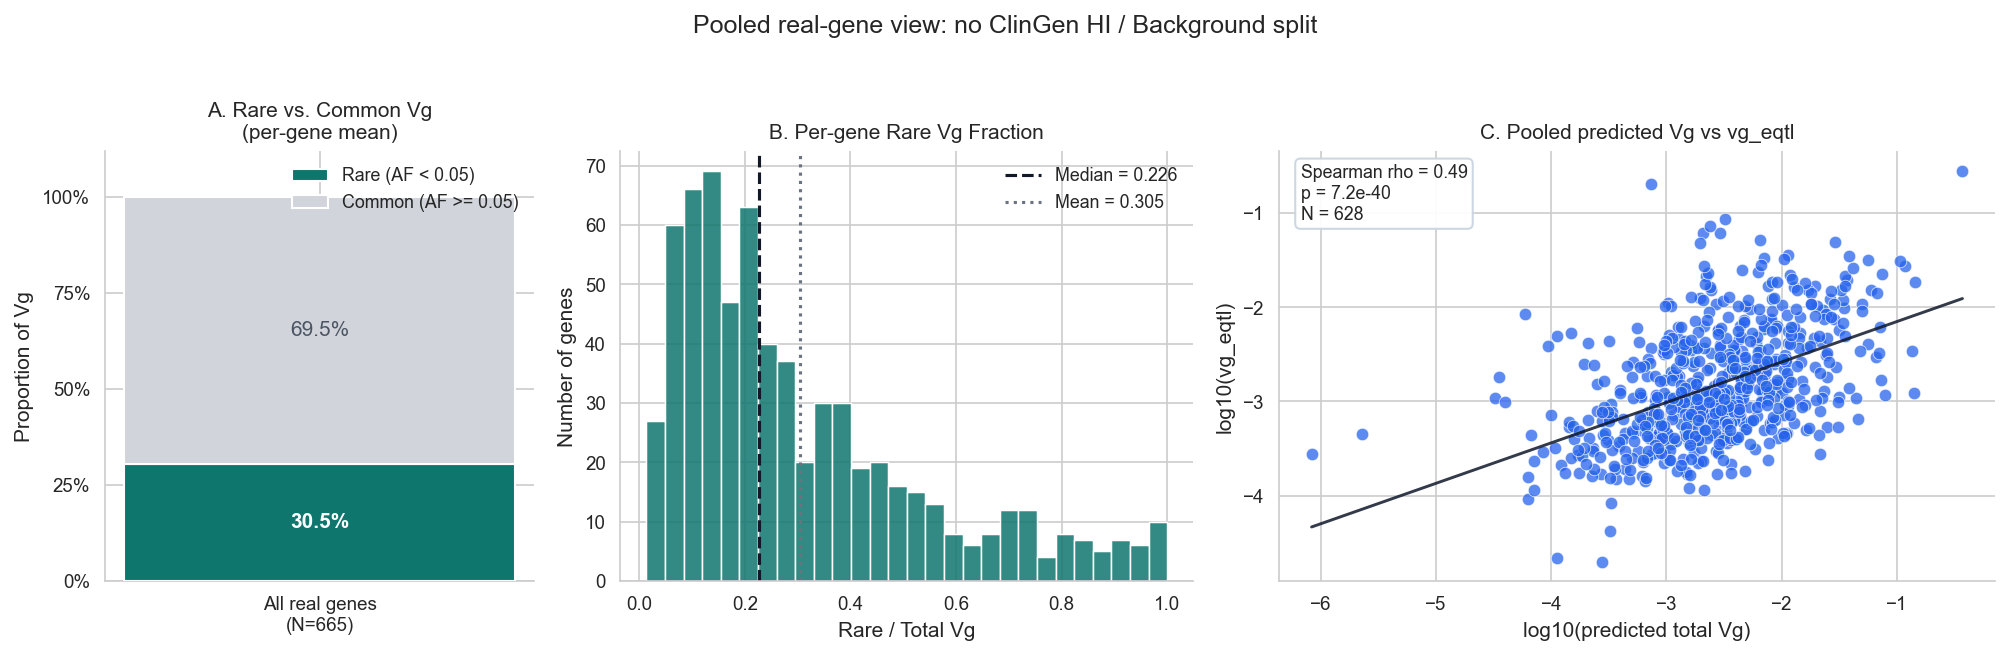

[save_plot] Saved: 07_vg_inspection_07_pooled_real_gene_vg_inspection_23032026_1828.pdf
[save_plot] Saved: 07_vg_inspection_07_pooled_real_gene_vg_inspection_23032026_1828.svg


<Figure size 960x720 with 0 Axes>

In [7]:
# -------------------------------------------------
# Pooled real-gene inspection: ClinGen HI + Background together
# -------------------------------------------------
real_summary = pd.DataFrame([
    {
        'n_genes': int(len(real_pooled_df)),
        'median_total_vg': float(real_pooled_df['vg_total_for_plot'].median()),
        'mean_total_vg': float(real_pooled_df['vg_total_for_plot'].mean()),
        'median_common_vg': float(real_pooled_df['vg_common_for_plot'].median()),
        'median_rare_vg': float(real_pooled_df['vg_rare_for_plot'].median()),
        'median_rare_fraction': float(real_pooled_df['vg_rare_fraction'].median()),
        'mean_rare_fraction': float(real_pooled_df['vg_rare_fraction'].mean()),
    }
])

corr_df = real_pooled_df[['gene_symbol', 'vg_total_for_plot', 'vg_eqtl']].dropna().copy()
rho, pval = stats.spearmanr(corr_df['vg_total_for_plot'], corr_df['vg_eqtl'])

corr_plot_df = corr_df.copy()
corr_plot_df['log10_total_vg'] = np.log10(corr_plot_df['vg_total_for_plot'].clip(lower=1e-12))
corr_plot_df['log10_vg_eqtl'] = np.log10(corr_plot_df['vg_eqtl'].clip(lower=1e-12))

rare_fraction = real_pooled_df['vg_rare_fraction'].dropna().values
rare_mean = float(np.mean(rare_fraction))
common_mean = 1 - rare_mean
rare_median = float(np.median(rare_fraction))
pool_label = 'All real genes' + '\n' + f'(N={len(real_pooled_df)})'
bar_title = 'A. Rare vs. Common Vg' + '\n' + '(per-gene mean)'

print('Pooled real-gene summary (ClinGen HI + Background combined; no null):')
print(real_summary.round(6).to_string(index=False))
print()
print(f'Spearman(total predicted Vg, vg_eqtl) across pooled real genes: rho={rho:.3f}, p={pval:.2e}, n={len(corr_df)}')

with autosave('07_pooled_real_gene_vg_inspection', notebook=NOTEBOOK_NAME):
    fig, (ax_bar, ax_hist, ax_scatter) = plt.subplots(
        1, 3, figsize=(13.5, 4.2),
        gridspec_kw={'width_ratios': [0.9, 1.2, 1.5]}
    )

    x = np.array([0])
    bw = 0.58
    ax_bar.bar(
        x, [rare_mean], bw,
        color=AF_STACK_COLORS['Rare (AF < 0.05)'],
        zorder=3, label='Rare (AF < 0.05)'
    )
    ax_bar.bar(
        x, [common_mean], bw, bottom=[rare_mean],
        color=AF_STACK_COLORS['Common (AF >= 0.05)'],
        zorder=3, label='Common (AF >= 0.05)'
    )
    ax_bar.text(0, rare_mean / 2, f'{rare_mean * 100:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    ax_bar.text(0, rare_mean + common_mean / 2, f'{common_mean * 100:.1f}%', ha='center', va='center',
                fontsize=10, color='#4B5563')
    ax_bar.set_xticks([0])
    ax_bar.set_xticklabels([pool_label], fontsize=9)
    ax_bar.set_ylim(0, 1.12)
    ax_bar.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax_bar.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=9)
    ax_bar.set_ylabel('Proportion of Vg', fontsize=10)
    ax_bar.set_title(bar_title, fontsize=10)
    ax_bar.legend(frameon=False, fontsize=8.5, loc='upper right')
    sns.despine(ax=ax_bar)

    sns.histplot(rare_fraction, bins=28, color=AF_STACK_COLORS['Rare (AF < 0.05)'],
                 edgecolor='white', alpha=0.85, ax=ax_hist)
    ax_hist.axvline(rare_median, color='#111827', lw=1.5, ls='--', label=f'Median = {rare_median:.3f}')
    ax_hist.axvline(rare_mean, color='#6B7280', lw=1.5, ls=':', label=f'Mean = {rare_mean:.3f}')
    ax_hist.set_xlabel('Rare / Total Vg', fontsize=10)
    ax_hist.set_ylabel('Number of genes', fontsize=10)
    ax_hist.set_title('B. Per-gene Rare Vg Fraction', fontsize=10)
    ax_hist.legend(frameon=False, fontsize=8.5)
    ax_hist.tick_params(axis='both', labelsize=9)
    sns.despine(ax=ax_hist)

    sns.scatterplot(
        data=corr_plot_df,
        x='log10_total_vg',
        y='log10_vg_eqtl',
        s=36,
        alpha=0.75,
        color=POOL_SCATTER_COLOR,
        edgecolor='white',
        linewidth=0.4,
        ax=ax_scatter,
    )
    sns.regplot(
        data=corr_plot_df,
        x='log10_total_vg',
        y='log10_vg_eqtl',
        scatter=False,
        ci=None,
        line_kws={'color': '#0F172A', 'lw': 1.4, 'alpha': 0.85},
        ax=ax_scatter,
    )
    annotation_text = '\n'.join([
        f'Spearman rho = {rho:.2f}',
        f'p = {pval:.1e}',
        f'N = {len(corr_df)}',
    ])
    ax_scatter.annotate(
        annotation_text,
        xy=(0.03, 0.97),
        xycoords='axes fraction',
        ha='left',
        va='top',
        fontsize=8.5,
        bbox={'boxstyle': 'round,pad=0.3', 'fc': 'white', 'ec': '#CBD5E1', 'alpha': 0.95},
    )
    ax_scatter.set_xlabel('log10(predicted total Vg)', fontsize=10)
    ax_scatter.set_ylabel('log10(vg_eqtl)', fontsize=10)
    ax_scatter.set_title('C. Pooled predicted Vg vs vg_eqtl', fontsize=10)
    ax_scatter.tick_params(axis='both', labelsize=9)
    sns.despine(ax=ax_scatter)

    plt.suptitle('Pooled real-gene view: no ClinGen HI / Background split', fontsize=12, y=1.03)
    plt.tight_layout()
    plt.show()
